# Capítulo 19 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 19. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

## T1 — A gaussiana sai da equação de difusão

**Solução.** Advecção-difusão estacionária com vento $U$ em $x$ e difusão transversal:
$$U\frac{\partial C}{\partial x} = K_y\frac{\partial^2 C}{\partial y^2} + K_z\frac{\partial^2 C}{\partial z^2}.$$
Trocando $t = x/U$, vira a equação do calor 2-D, cuja solução para fonte pontual é a gaussiana com $\sigma_y^2 = 2K_yx/U$ e $\sigma_z^2 = 2K_zx/U$. A conservação de massa fixa o prefator $Q/(2\pi U\sigma_y\sigma_z)$: o que passa por qualquer plano $x$ por segundo é sempre $Q$. As potências empíricas $\sigma \propto x^{0,9}$ das classes de Pasquill refletem $K$ crescendo com a escala da pluma (turbulência sem escala própria, Cap. 18). ∎

## T2 — A fonte-imagem

**Solução.** O chão não absorve (fluxo nulo): $\partial C/\partial z = 0$ em $z = 0$. Somar uma fonte-imagem em $z = -H$ garante a condição por simetria — exatamente o método das imagens da eletrostática (a turma reconhece de Griffiths!), com o fluxo de massa no papel do campo. No solo os dois termos são iguais e a concentração **dobra**. Para camada de mistura com tampa em $z_i$, refletem-se imagens infinitas (chão e teto), somadas até convergir. ∎

## T3 — O máximo no solo

In [2]:
# C_solo(x) com sigma_z = a x^b, sigma_y ∝ sigma_z: maximizar em x
x, H_, a_, b_, s = sp.symbols('x H a b sigma_z', positive=True)
# C_solo ∝ (1/sz²) exp(-H²/2sz²)   (com sy ∝ sz)
C = 1/s**2*sp.exp(-H_**2/(2*s**2))
dC = sp.diff(C, s)
sz_max = sp.solve(dC, s)
print('dC/dsigma = 0 em sigma_z =', sz_max)
print()
print('=> sigma_z(x_max) = H/sqrt(2): o maximo no solo ocorre onde a pluma')
print('cresceu ate ~70% da altura da chamine. Substituindo de volta:')
print('C_max ∝ 1/H² — dobrar a chamine reduz o pico a 1/4 (verificado no N1).')

dC/dsigma = 0 em sigma_z = [sqrt(2)*H/2]

=> sigma_z(x_max) = H/sqrt(2): o maximo no solo ocorre onde a pluma
cresceu ate ~70% da altura da chamine. Substituindo de volta:
C_max ∝ 1/H² — dobrar a chamine reduz o pico a 1/4 (verificado no N1).


## T4 — O modelo de caixa e a ventilação

**Solução.** Balanço de massa na caixa cidade (largura $W$, teto $z_i$, vento $U$): entra emissão $Q_A W$ (por metro transversal), sai $U z_i C$. Logo
$$z_i\frac{dC}{dt} = Q_A - \frac{Uz_i}{W}C\quad\Rightarrow\quad C_{eq} = \frac{Q_A W}{U z_i}.$$
O denominador $Uz_i$ é o **fator de ventilação** (m²/s): a vazão de ar limpo por metro de cidade. Inverno estagnado: $U z_i$ cai de ~10 000 para ~600 m²/s — e a MESMA emissão dá 15× mais concentração. É o número que os órgãos ambientais monitoram para decretar episódios. ∎

## T5 — Passeio aleatório → difusão

In [3]:
# passos independentes de tamanho l a cada tau: var(N passos) = N l²
print('Passos independentes: sigma²(t) = (t/tau)·l² = 2Kt com K = l²/(2tau).')
print('Com velocidade sigma_w mantida por T_L: l = sigma_w·T_L, tau = T_L =>')
print('K = sigma_w²·T_L/2 (fator O(1) conforme a definicao de T_L).')
print()
print('Teorema de Taylor (1921): sigma²(t) = 2sigma_w²∫(t-s)R(s)ds, com')
print('R = exp(-s/T_L): balistico (sigma ∝ t) para t<<T_L, difusivo')
print('(sigma ∝ sqrt(t)) para t>>T_L — exatamente o cotovelo do Caso 4.')
print('E o mesmo Langevin do movimento browniano: Einstein 1905 com')
print('turbulencia no lugar das moleculas.')

Passos independentes: sigma²(t) = (t/tau)·l² = 2Kt com K = l²/(2tau).
Com velocidade sigma_w mantida por T_L: l = sigma_w·T_L, tau = T_L =>
K = sigma_w²·T_L/2 (fator O(1) conforme a definicao de T_L).

Teorema de Taylor (1921): sigma²(t) = 2sigma_w²∫(t-s)R(s)ds, com
R = exp(-s/T_L): balistico (sigma ∝ t) para t<<T_L, difusivo
(sigma ∝ sqrt(t)) para t>>T_L — exatamente o cotovelo do Caso 4.
E o mesmo Langevin do movimento browniano: Einstein 1905 com
turbulencia no lugar das moleculas.


---
## N1 — Altura da chaminé

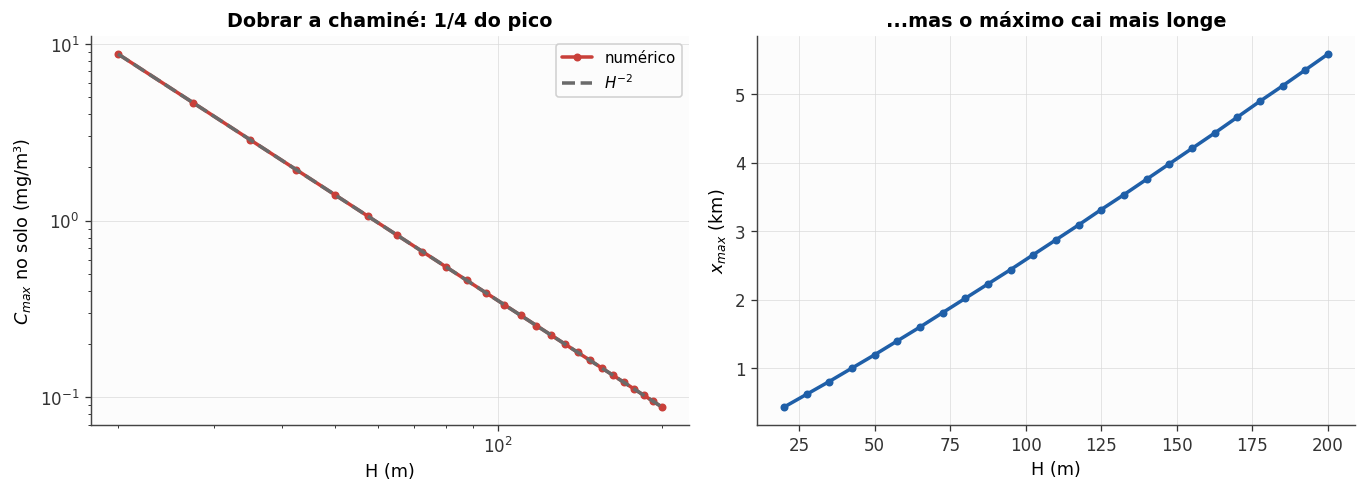

a politica das chamines altas dos anos 70 diluiu localmente — e exportou
o problema (chuva acida a centenas de km): fisica correta, solucao incompleta.


In [4]:
Q, U = 100.0, 5.0
a_y, a_z, b = 0.08, 0.06, 0.9
x = np.linspace(50, 30000, 4000)

def pico_solo(H):
    sy, sz = a_y*x**b, a_z*x**b
    C = Q/(np.pi*U*sy*sz)*np.exp(-H**2/(2*sz**2))   # solo: fator 2 da imagem
    i = np.argmax(C)
    return C[i]*1e3, x[i]

Hs = np.linspace(20, 200, 25)
res = np.array([pico_solo(H) for H in Hs])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.loglog(Hs, res[:, 0], 'o-', ms=4, color=CORES['vermelho'], label='numérico')
ax1.loglog(Hs, res[8, 0]*(Hs/Hs[8])**-2, '--', color=CORES['cinza'], label='$H^{-2}$')
ax1.set(xlabel='H (m)', ylabel='$C_{max}$ no solo (mg/m³)',
        title='Dobrar a chaminé: 1/4 do pico')
ax1.legend()
ax2.plot(Hs, res[:, 1]/1e3, 'o-', ms=4, color=CORES['azul'])
ax2.set(xlabel='H (m)', ylabel='$x_{max}$ (km)',
        title='...mas o máximo cai mais longe')
fig.tight_layout(); plt.show()
print('a politica das chamines altas dos anos 70 diluiu localmente — e exportou')
print('o problema (chuva acida a centenas de km): fisica correta, solucao incompleta.')

## N2 — Fumigação da manhã

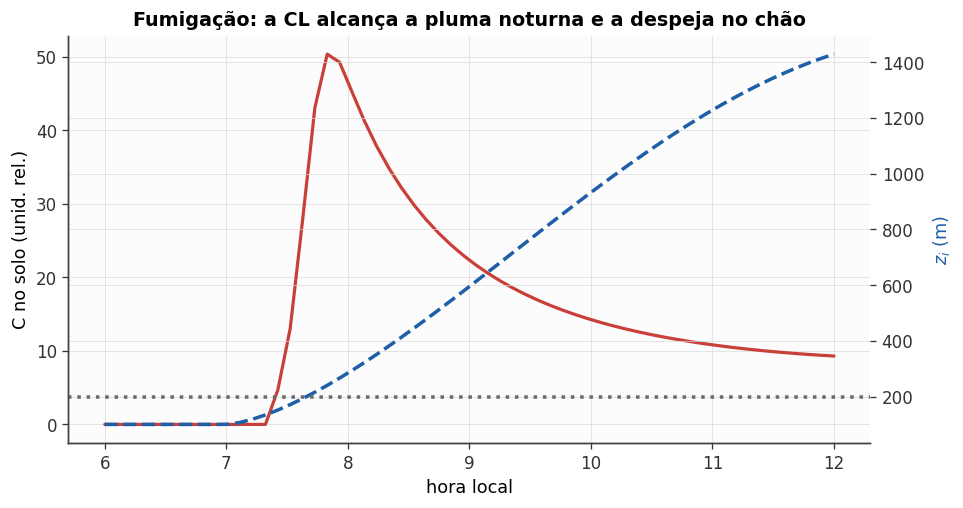

pico de fumigacao ~8h: a pluma da madrugada inteira desce
quase de uma vez quando zi cruza os 200 m — o pico matinal classico das
cidades industriais (e a razao de medir sondagem as 8h).


In [5]:
Q, U, H = 100.0, 3.0, 200.0                    # pluma noturna alta e fina
W_pluma = 30.0                                  # sigma_z da noite (fanning)
x_cid = 5000.0                                  # cidade a 5 km

horas = np.linspace(6, 12, 60)
zi_t = 100 + 1400*np.clip(np.sin(np.pi*(horas - 7)/12), 0, None)**1.5
C_solo = []
for zi in zi_t:
    if zi < H - 2*W_pluma:
        C_solo.append(0.0)                     # pluma ainda acima da CL
    else:
        # fração capturada da gaussiana, misturada na caixa 0..zi
        from math import erf
        frac = 0.5*(1 + erf((zi - H)/(np.sqrt(2)*W_pluma)))
        C_solo.append(frac*Q/(U*np.sqrt(2*np.pi)*W_pluma)*np.exp(0)*W_pluma/zi*1e3)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(horas, C_solo, color=CORES['vermelho'], lw=2)
ax2 = ax.twinx()
ax2.plot(horas, zi_t, '--', color=CORES['azul'])
ax2.axhline(H, color=CORES['cinza'], ls=':')
ax.set(xlabel='hora local', ylabel='C no solo (unid. rel.)',
       title='Fumigação: a CL alcança a pluma noturna e a despeja no chão')
ax2.set_ylabel('$z_i$ (m)', color=CORES['azul'])
plt.show()
imax = np.argmax(C_solo)
print(f'pico de fumigacao ~{horas[imax]:.0f}h: a pluma da madrugada inteira desce')
print('quase de uma vez quando zi cruza os 200 m — o pico matinal classico das')
print('cidades industriais (e a razao de medir sondagem as 8h).')

## N3 — Tráfego × ventilação

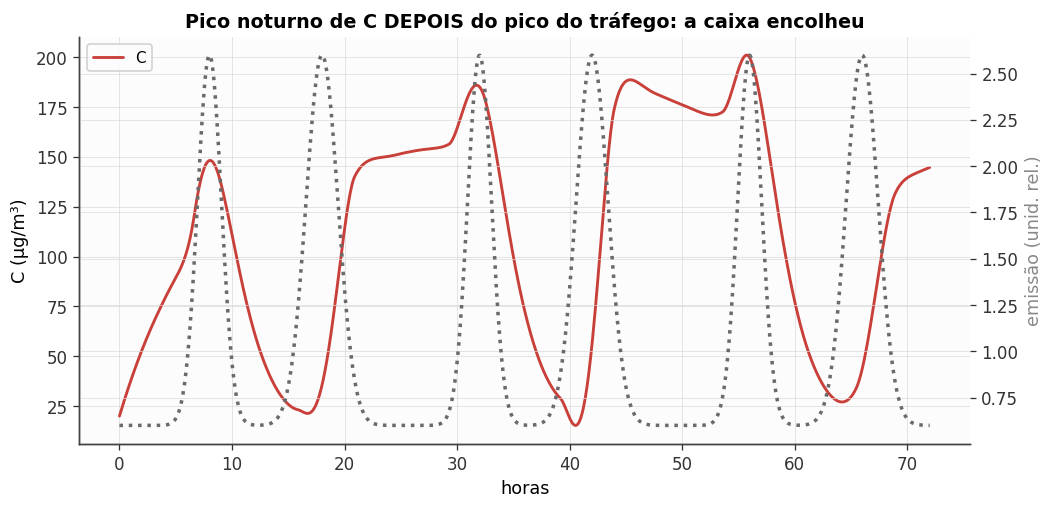

o rush das 18h emite dentro de uma caixa que esta ENCOLHENDO (zi caindo,
vento morrendo): C sobe ate 20-22h mesmo com emissao ja em queda —
o classico maximo noturno de CO/MP das grandes cidades.


In [6]:
W = 40e3
def QA_traf(t_h):
    h = t_h % 24
    return 2e-6*(0.3 + np.exp(-((h - 8)/1.5)**2) + np.exp(-((h - 18)/2.0)**2))

def zi_dia(t_h):
    h = t_h % 24
    return 100 + 900*max(np.sin(np.pi*(h - 7)/12), 0) if 7 <= h <= 19 else 100.0

def U_dia(t_h):
    h = t_h % 24
    return 1.5 + 2.5*max(np.sin(np.pi*(h - 7)/12), 0)

def caixa(t, C):
    th = t/3600
    zi, U = zi_dia(th), U_dia(th)
    return [(QA_traf(th) - U*zi/W*C[0])/zi]

t_eval = np.linspace(0, 72*3600, 900)
s = solve_ivp(caixa, [0, 72*3600], [20e-6], t_eval=t_eval, rtol=1e-8)
h = (t_eval/3600) % 24

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(t_eval/3600, s.y[0]*1e6, color=CORES['vermelho'], lw=1.8, label='C')
ax2 = ax.twinx()
ax2.plot(t_eval/3600, [QA_traf(x)*1e6 for x in t_eval/3600], ':',
         color=CORES['cinza'], label='emissão')
ax.set(xlabel='horas', ylabel='C (µg/m³)',
       title='Pico noturno de C DEPOIS do pico do tráfego: a caixa encolheu')
ax2.set_ylabel('emissão (unid. rel.)', color='#888888')
ax.legend(loc='upper left')
plt.show()
print('o rush das 18h emite dentro de uma caixa que esta ENCOLHENDO (zi caindo,')
print('vento morrendo): C sobe ate 20-22h mesmo com emissao ja em queda —')
print('o classico maximo noturno de CO/MP das grandes cidades.')

## N4 — $K = \sigma_w^2 T_L$

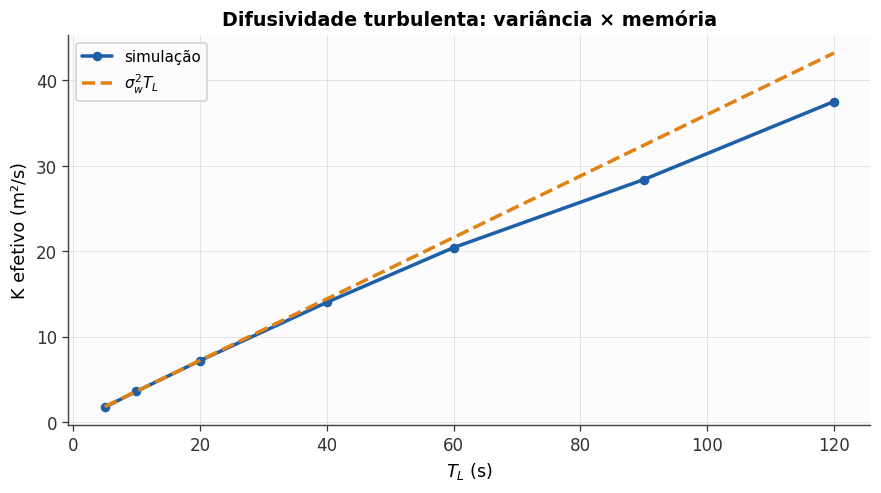

K ∝ sigma_w² T_L confere. Perto da fonte (t < T_L) o espalhamento e
BALISTICO (sigma ∝ t, nao sqrt(t)): plumas jovens crescem linearmente —
por isso os sigma_y de Pasquill comecam ~lineares em x.


In [7]:
rng = np.random.default_rng(44)
sigma_w, dt = 0.6, 1.0
n_part, T_tot = 2000, 1200

def K_efetivo(T_L):
    a = np.exp(-dt/T_L)
    w = np.zeros(n_part); zp = np.zeros(n_part)
    n = int(T_tot/dt)
    for _ in range(n):
        w = a*w + np.sqrt(1 - a**2)*sigma_w*rng.standard_normal(n_part)
        zp = zp + w*dt
    return np.var(zp)/(2*T_tot)

TLs = np.array([5, 10, 20, 40, 60, 90, 120])
Ks = [K_efetivo(TL) for TL in TLs]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(TLs, Ks, 'o-', ms=5, color=CORES['azul'], label='simulação')
ax.plot(TLs, sigma_w**2*TLs, '--', color=CORES['laranja'], label='$\\sigma_w^2 T_L$')
ax.set(xlabel='$T_L$ (s)', ylabel='K efetivo (m²/s)',
       title='Difusividade turbulenta: variância × memória')
ax.legend()
plt.show()
print('K ∝ sigma_w² T_L confere. Perto da fonte (t < T_L) o espalhamento e')
print('BALISTICO (sigma ∝ t, nao sqrt(t)): plumas jovens crescem linearmente —')
print('por isso os sigma_y de Pasquill comecam ~lineares em x.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*